# Stage 03: Python Fundamentals Submission

This notebook demonstrates NumPy operations, vectorized execution, pandas inspection and aggregation, reusable functions, saved outputs, and a basic plot.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import get_category_summary, get_summary_stats

RAW_DATA_PATH = PROJECT_ROOT / "data/raw/starter_data.csv"
PROCESSED_DIR = PROJECT_ROOT / "data/processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/kevin/Desktop/NYU/bootcamp/bootcamp_zizhe_zhou/homework/stage3


## 1. NumPy Operations

The following operations are applied element by element without manually iterating through the array.

In [2]:
values = np.array([1, 2, 3, 4, 5])
print("Original:", values)
print("Add 10:", values + 10)
print("Squared:", values**2)
print("Scaled and shifted:", values * 2 + 1)

Original: [1 2 3 4 5]
Add 10: [11 12 13 14 15]
Squared: [ 1  4  9 16 25]
Scaled and shifted: [ 3  5  7  9 11]


## 2. Loop vs. Vectorized Execution

Both approaches produce the same result, but NumPy performs the work in optimized compiled code. Timings vary by machine, so they are reported rather than used as a strict test.

In [3]:
large_array = np.arange(200_000, dtype=float)

start = time.perf_counter()
loop_result = np.array([value * 2 + 1 for value in large_array])
loop_seconds = time.perf_counter() - start

start = time.perf_counter()
vectorized_result = large_array * 2 + 1
vectorized_seconds = time.perf_counter() - start

print("Results match:", np.array_equal(loop_result, vectorized_result))
print(f"Loop time: {loop_seconds:.6f} seconds")
print(f"Vectorized time: {vectorized_seconds:.6f} seconds")
print(f"Observed speedup: {loop_seconds / vectorized_seconds:.1f}x")

Results match: True
Loop time: 0.016589 seconds
Vectorized time: 0.000492 seconds
Observed speedup: 33.7x


## 3. Load and Inspect the Dataset

In [4]:
df = pd.read_csv(RAW_DATA_PATH, parse_dates=["date"])
print("First five rows:")
display(df.head())
print("\nDataFrame information:")
df.info()

First five rows:


,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05



DataFrame information:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   category  10 non-null     str           
 1   value     10 non-null     int64         
 2   date      10 non-null     datetime64[us]
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 372.0 bytes


## 4. Summary Statistics and Groupby Aggregation

The reusable functions in `src/utils.py` calculate numeric descriptive statistics and category-level aggregations.

In [5]:
summary_stats = get_summary_stats(df)
category_summary = get_category_summary(df)

print("Numeric summary statistics:")
display(summary_stats)
print("Category aggregation:")
display(category_summary)

Numeric summary statistics:


,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


Category aggregation:


,category,count,mean,minimum,maximum,total
0,A,4,11.500000,10,13,46
1,B,3,15.666667,14,18,47
2,C,3,27.666667,25,30,83


## 5. Save Processed Outputs

In [6]:
summary_path = PROCESSED_DIR / "summary.csv"
groupby_path = PROCESSED_DIR / "groupby_summary.csv"
summary_stats.to_csv(summary_path)
category_summary.to_csv(groupby_path, index=False)

print("Saved:", summary_path.relative_to(PROJECT_ROOT))
print("Saved:", groupby_path.relative_to(PROJECT_ROOT))

Saved: data/processed/summary.csv
Saved: data/processed/groupby_summary.csv


## Bonus: Basic Plot

This bar chart compares the mean `value` for each category.

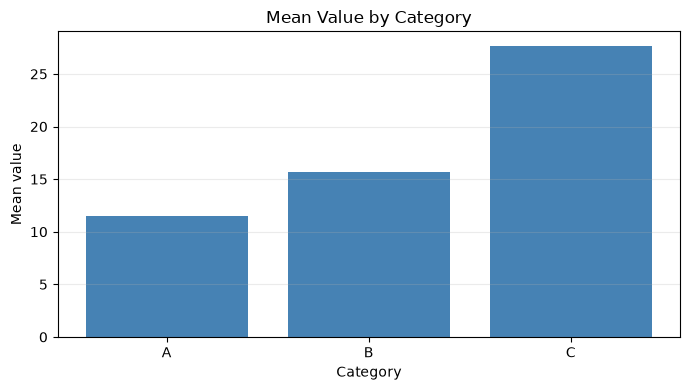

Saved: reports/category_mean_value.png


In [7]:
figure, axis = plt.subplots(figsize=(7, 4))
axis.bar(category_summary["category"], category_summary["mean"], color="steelblue")
axis.set(title="Mean Value by Category", xlabel="Category", ylabel="Mean value")
axis.grid(axis="y", alpha=0.25)
figure.tight_layout()
plot_path = REPORTS_DIR / "category_mean_value.png"
figure.savefig(plot_path, dpi=150)
plt.show()
print("Saved:", plot_path.relative_to(PROJECT_ROOT))

## Findings

The dataset contains ten complete observations across categories A, B, and C. Category C has the highest average value, followed by B and A. This small example demonstrates the complete path from raw data through reusable analysis code to saved tables and a stakeholder-friendly visual.